# Notebook for Processing TR-XRD Data using the TRXRD Code

**Edit the settings cell below before running this notebook.**

## Import Necessary Packages

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import gaussian_filter1d

import trxrd

%matplotlib widget

## Define Experimental Parameters

In [103]:
# Experimental Parameters and Defaults
# ============================================================
# Data and Mask Paths, Scan Name, and Filename Pattern
# ============================================================
DATA_PATH = Path(r"\\s7data\beams46\7IDC\Cotts\2025_11Exp\BTO400_S3") # Path to directory containing TIFF files
MASK_FILE = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\TRXRDPython\testdata\mask_2021_dec.tif") # Path to mask file
SCAN_NAME = "BTO400nmS3_285Khalfpow2" # Prefix in file name to identify relevant files, e.g. "550nm_re" etc.
SCAN_TYPE = "delay_scan" # Type of scan based on filename pattern, e.g. "delay_scan", "theta_samz", etc. Must correspond to a key in the "filename_patterns" dictionary in trxrd.py
BACKGROUND_PATH = Path(r"\\s7data\beams46\7IDC\Cotts\2025_11Exp\BlankSubstratePinkBeam\blanksubstratePinkBeam-1.0fshw-4e-09delay00004_020.tif")
SAVE_PATH = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\BTO_31.2keV\BTO400nmS3_285Khalfpow2") # Path to directory where processed data will be saved, e.g. as .h5 file
# PONI file from pyFAI-calib2. Set to a Path to use PONI geometry;
# set to None to use the manual parameters below.
PONI_FILE = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\CeO2\poni_files\CeO2_calib_poni.poni") # Path to .poni file, or None

# ============================================================
# General Defaults
# ============================================================
FIGSIZE = (10, 4)
STD_FACTOR = 3
MAX_PROCESSORS = 4
DELAY_SIGN = -1 # Check file naming scheme, sometimes positives delays have "-" in front and negative have no sign so need to invert sign

# ============================================================
# Beam Stop Mask Defaults
# ============================================================
MASK_CENTER_X = 52
MASK_CENTER_Y = 1667
MASK_RADIUS = 30

# ============================================================
# Center Guess and Sampling Defaults
# ============================================================
CENTER_X = 44
CENTER_Y = 1666
DOWNSAMPLE = 2 # Downsample factor for center finding, e.g. 2 means use every other pixel, 4 means use every 4th pixel, etc.

# ============================================================
# Detector Parameters and Defaults
# ============================================================

# Detector and beam parameters
PIXEL1 = 1.72e-4                 # m, detector pixel size along rows (y)
PIXEL2 = 1.72e-4                 # m, detector pixel size along cols (x)
DISTANCE = 0.1723                 # m, sample-to-detector distance
WAVELENGTH = 0.39738514824147314e-10          # m

# Detector orientation
TILT_ANGLE = np.deg2rad(0)               # rad
TILT_PLANE_ROTATION = np.deg2rad(90)      # rad
ROT3 = 0.0                      # rad, in-plane detector rotation

# Optional corrections
POLARIZATION_FACTOR = 0.999      # e.g. 0.99 or None
DARK = None                     # 2D dark image or None
FLAT = None                     # 2D flat-field image or None

# ============================================================
# Azimuthal Averaging and Normalization Defaults
# ============================================================
UNIT = "q_A^-1" # Unit for x-axis of azimuthally averaged data, e.g. "q_A^-1" for inverse Angstroms, "2theta_deg" for degrees, etc. 
NAN_MIN = 0.35 # Minimum value for valid data, values below this will be set to NaN, e.g. 0.35 or None for no minimum threshold
NAN_MAX = None # Maximum value for valid data, values above this will be set to NaN, e.g. 1.0 or None for no maximum threshold
NORM_MIN = 4.05 # Minimum value for normalization, values below this will be set to this value before normalization, e.g. 0.5 or None for no minimum threshold
NORM_MAX = 4.25 # Maximum value for normalization, values above this will be set to this value before normalization, e.g. 1.0 or None for no maximum threshold
N_POINTS = 3000 # Number of points for azimuthal averaging, e.g. 3000 or None to use all pixels

# ============================================================
# Background Subtraction Defaults
# ============================================================
BACKGROUND_NORM_MIN = 1.0 # Minimum value for background normalization, values below this will be set to this value before normalization, e.g. 0.5 or None for no minimum threshold
BACKGROUND_NORM_MAX = 1.5 # Maximum value for background normalization, values above this will be set to this value before normalization, e.g. 1.0 or None for no maximum threshold

# ============================================================
# Baseline Subtraction Defaults
# ============================================================
LAM_VAL = 1e4
P_VAL = 0.05

# ============================================================
# PDF Calcuation Defaults
# ============================================================
COMPOSITION = "BaTiO3" # Sample composition for form factor calculation, e.g. "BaTiO3" or None for no form factor correction
R_MAX = 20.0 # Maximum r value for PDF calculation, e.g. 20.0 or None for no maximum
N_R = 2000 # Number of r points for PDF calculation, e.g.
Q_MIN = 0.5 # Minimum q value for PDF calculation, e.g. 0.5 or None for no minimum
Q_MAX = 15.0 # Maximum q value for PDF calculation, e.g. 16.0 or None for no maximum
WINDOW = "lorch" # Window function for PDF calculation, e.g. "lorch", "hanning", "blackman", or None for no window
# ============================================================
# Optional Saving .dat Files
# ============================================================
SAVE_AZAV_DAT = True # Whether to save azimuthally averaged profiles as .dat files in addition to the .h5 file, e.g. True or False
# ============================================================
# Form Factor CSV File
# ============================================================
FORM_FACTOR_FILE = Path(
    r"C:\Users\lheald\Documents\Guzelturk_Lab\gued\packages\x_ray_ff\atomic_FF_coeffs_clean.csv"
)

## Define File Paths

In [104]:
# Main diffraction data folder
data_path = DATA_PATH

# Check number of files in folder 
file_names = sorted(data_path.glob(f"{SCAN_NAME}-*.tif"))
print(f"{len(file_names)} TIFF files found in {data_path}.")

# Detector mask file
mask_file = MASK_FILE
print(f"Using mask file: {mask_file}")

1078 TIFF files found in \\s7data\beams46\7IDC\Cotts\2025_11Exp\BTO400_S3.
Using mask file: C:\Users\lheald\Documents\Guzelturk_Lab\TRXRDPython\testdata\mask_2021_dec.tif


## Import Images

This can take a few minutes if you're loading in hundreds of images. Might crash with thousands of images...

In [ ]:
data_dict = trxrd.get_image_details(
    folder_path=DATA_PATH,
    sample_name=SCAN_NAME,
    filename_scheme=SCAN_TYPE,
    sort_key="image_number",
    filter_data=[0,200],
    plot=True,
)
print(data_dict.keys())
print("Images shape:", data_dict["images"].shape)
print("Counts shape:", data_dict["counts"].shape)

if SCAN_TYPE == "theta_samz":
    print("Degrees:", np.unique(data_dict["degree"]))
    print("Theta:", np.unique(data_dict["theta"]))
    print("Samz:", np.unique(data_dict["samz"]))
elif SCAN_TYPE == "delay_scan":
    print("Fluences:", np.unique(data_dict["fluence"]))
    print("Delays:", np.unique(data_dict["delay"]))

1078 TIFF files found in \\s7data\beams46\7IDC\Cotts\2025_11Exp\BTO400_S3 with scan name BTO400nmS3_285Khalfpow2.


## Remove Images Based on Total Counts

0 images removed from 10 initial images


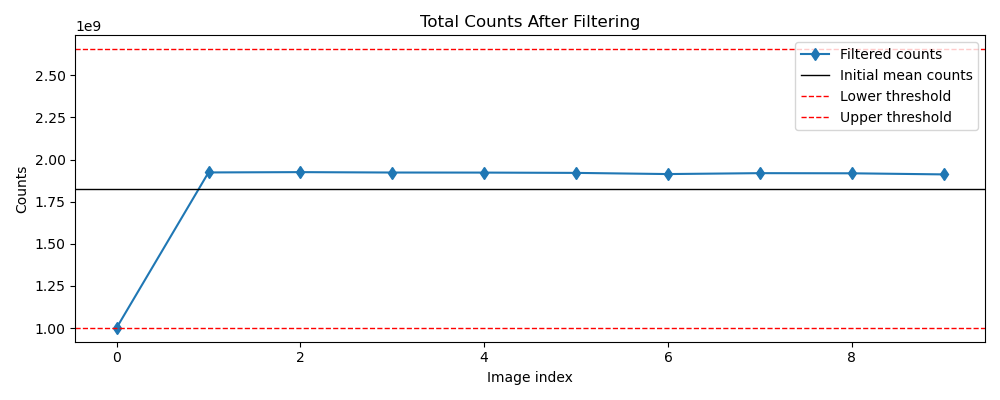

Clean images shape: (10, 1679, 1475)
Removed images: 0


In [51]:
count_result = trxrd.remove_counts(
    data_dict,
    std_factor=STD_FACTOR,
    added_range=None,   # e.g. [[10, 20]]
    plot=True,
    return_dict=True,
)

data_dict = count_result["filtered_data"]

print("Clean images shape:", data_dict["images"].shape)
print("Removed images:", count_result["n_removed"])

## Build Combined Masks

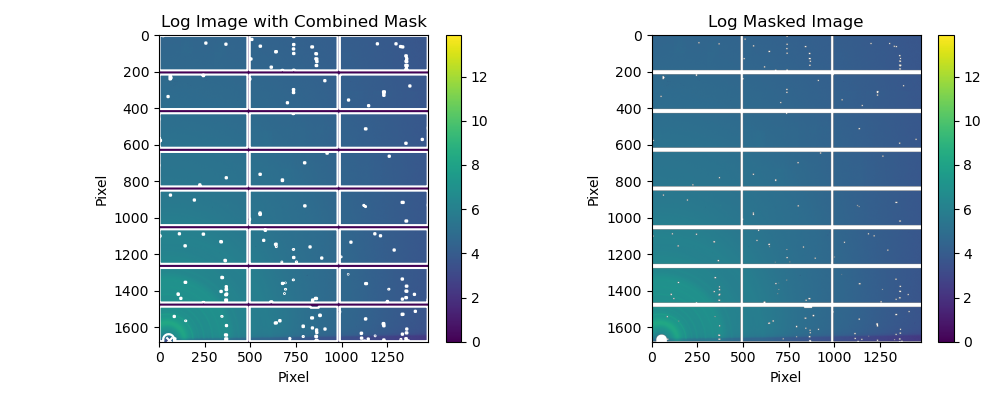

In [119]:
image_shape = data_dict["images"].shape[1:]   # (rows, cols)

combined_mask = trxrd.build_combined_mask(
    image_shape,
    center_xy = (MASK_CENTER_X, MASK_CENTER_Y),
    radius = MASK_RADIUS,
    detector_mask=None,
    mask_path=MASK_FILE,
    plot=True,
    example_image=data_dict["images"][0],
)

## Optionally Apply Mask

In [5]:
# data_dict["images"] = trxrd.apply_mask_from_bool(
#     data_array=data_dict["images"],
#     mask_bool=combined_mask,
# )

## Remove Hot Pixels

c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd.py:1299: RuntimeWarning: Mean of empty slice
  mean_image = np.nanmean(working_stack, axis=0)
c:\Users\lheald\AppData\Local\miniconda3\envs\research\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Removing hot pixels from 884 image(s)...
  Completed 100/884 (11.3%)
  Completed 200/884 (22.6%)
  Completed 300/884 (33.9%)
  Completed 400/884 (45.2%)
  Completed 500/884 (56.6%)
  Completed 600/884 (67.9%)
  Completed 700/884 (79.2%)
  Completed 800/884 (90.5%)
  Completed 884/884 (100.0%)
Done removing hot pixels.


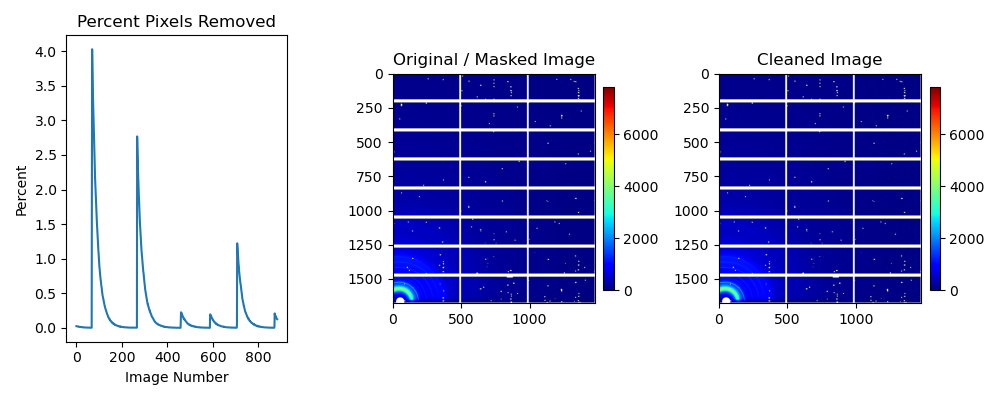

Mean percent pixels removed: 0.22098989059127375
Max percent pixels removed: 4.026318007414029


In [5]:
xr_result = trxrd.remove_xrays_pool(
    data_dict["images"],
    std_factor=STD_FACTOR,
    plot=True,
    image_index=0,
    return_dict=True,
    mask_bool=combined_mask,
    max_workers=MAX_PROCESSORS,
    progress_interval=100,
)

data_dict["images"] = xr_result["clean_data"]

print("Mean percent pixels removed:", np.nanmean(xr_result["pct_removed"]))
print("Max percent pixels removed:", np.nanmax(xr_result["pct_removed"]))

## Find Centers for Images

**Note for more precise center finding use the `Find_Centers.ipynb` notebook**

Finding centers for 70 images...
  Completed 70/70 (100.0%)
Done finding centers.


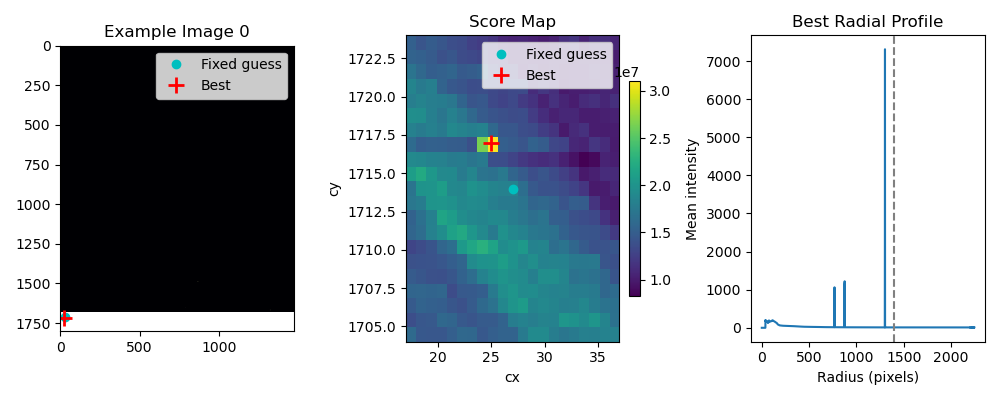

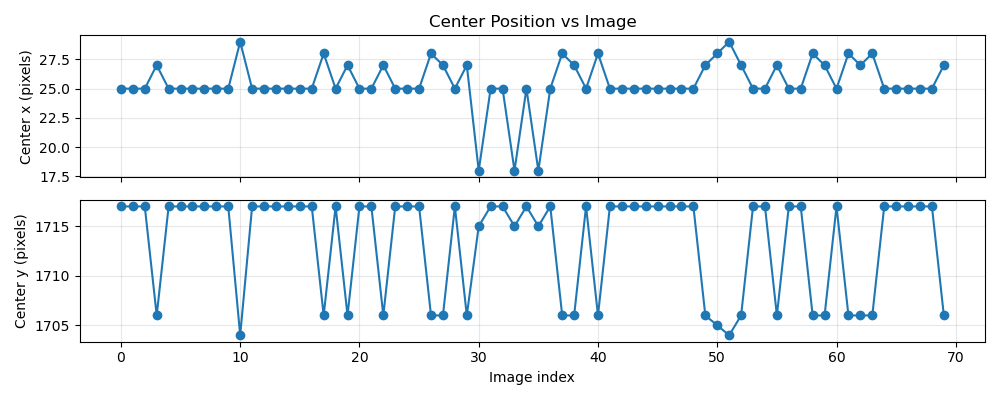

Centers shape: (70, 2)
First center: [  25. 1717.]
Mean center: [  25.5        1713.38571429]


In [5]:
center_result = trxrd.find_centers_in_stack_radial_parallel(
    data_array=data_dict["images"],
    center_guess_yx=(CENTER_Y, CENTER_X),   # note: (y, x)
    search_radius=10,
    center_mask=None,
    r_min=0,
    r_max=1400,
    downsample=1,
    intensity_threshold=None,
    top_percentile=60,
    max_workers=MAX_PROCESSORS,
    progress_interval=100,
    plot_example=True,
    example_index=0,
    plot_center_vs_image=True,
)

centers = center_result["centers_xy"]
print("Centers shape:", centers.shape)
print("First center:", centers[0])
mean_center = np.mean(centers, axis=0)
print(f"Mean center: {mean_center}")


## Compute Azimuthal Average

Using PONI geometry from file: C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\CeO2\poni_files\CeO2_calib_poni.poni
Integrating 500 images...
  Completed 100/500 (20.0%)
  Completed 200/500 (40.0%)
  Completed 300/500 (60.0%)
  Completed 400/500 (80.0%)
  Completed 500/500 (100.0%)
Done integrating.
q shape: (3000,)
profiles shape: (500, 3000)


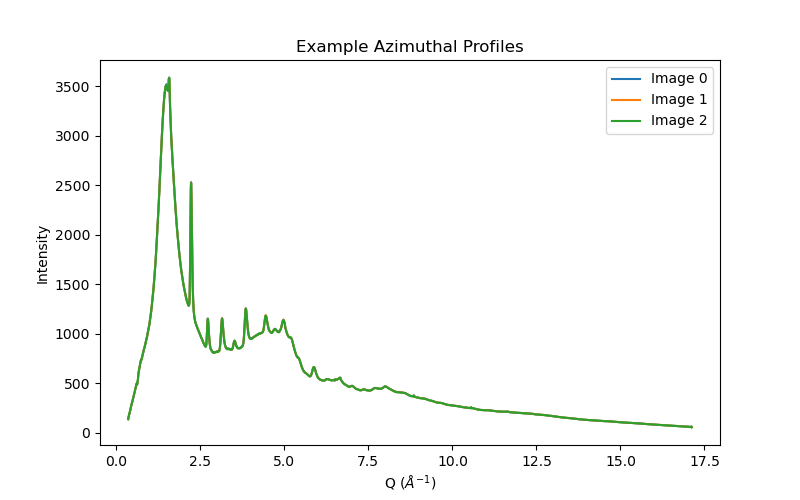

In [120]:
if PONI_FILE is not None:
    print(f"Using PONI geometry from file: {PONI_FILE}")
    az_result = trxrd.azimuthal_average_pyfai(
    images=data_dict["images"],
    centers_xy=None,   # note: (x, y)
    poni_path=PONI_FILE,
    npt=N_POINTS,
    unit=UNIT,
    nan_radial_range=(NAN_MIN, NAN_MAX),   # set Q < 0.3 to NaN
    azimuth_range=None,
    integration_mask=combined_mask,
    return_dict=True,
    progress_interval=100,
    use_custom_polarization=False,
    integration_function="integrate1d",
    correct_solid_angle=False,
    method=("bbox", "csr", "cython")
)
else:
    print("Using manual geometry parameters.")
    az_result = trxrd.azimuthal_average_pyfai(
        images=data_dict["images"],
        centers_xy=(CENTER_X, CENTER_Y),   # note: (x, y)
        polarization_factor=POLARIZATION_FACTOR,
        npt=N_POINTS,
        unit=UNIT,
        nan_radial_range=(NAN_MIN, NAN_MAX),   # set Q < 0.3 to NaN
        azimuth_range=None,
        integration_mask=combined_mask,
        return_dict=True,
        progress_interval=100,
        use_custom_polarization=False,
        integration_function="integrate1d",
        correct_solid_angle=False,
        method=("bbox", "csr", "cython")
    )

q = az_result["radial"]
profiles = az_result["profiles"]

print("q shape:", q.shape)
print("profiles shape:", profiles.shape)

plt.figure(figsize=(8, 5))
for i in [0, 1, 2]:
    plt.plot(q, profiles[i], label=f"Image {i}")
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Intensity")
plt.title("Example Azimuthal Profiles")
plt.legend()
plt.show()

## Normalize Azimuthal Averages

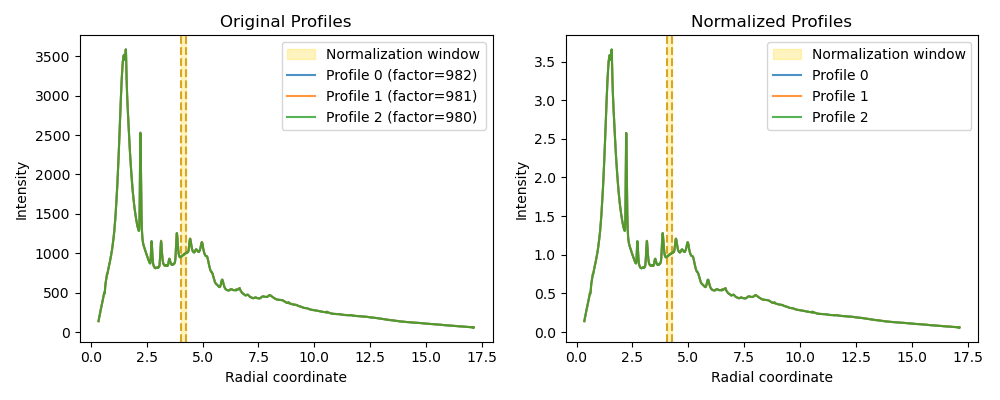

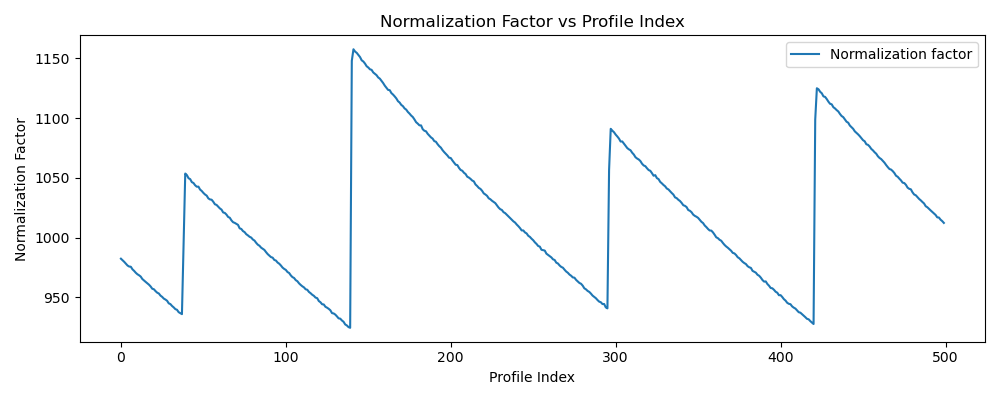

In [121]:
norm_result = trxrd.normalize_profiles_to_range(
    radial=q,
    profiles=profiles,
    norm_range=(NORM_MIN, NORM_MAX),   # example
    mode="mean",
    plot=True,
    plot_indices=[0, 1, 2],
    show_normalized_plot=True,
    return_dict=True,
    plot_factors=True,
)

profiles_norm = norm_result["normalized_profiles"]

## Load and Prepare Background Image(s)

**Make sure you're treating the background and the data the same! i.e., same masks, same centers, etc**

Loading background from: \\s7data\beams46\7IDC\Cotts\2025_11Exp\BlankSubstratePinkBeam\blanksubstratePinkBeam-1.0fshw-4e-09delay00004_020.tif
dict_keys(['files', 'background_stack', 'background_mean', 'background_std', 'n_images'])
Background stack shape: (1, 1679, 1475)
Background mean shape: (1679, 1475)


C:\Users\lheald\AppData\Local\Temp\ipykernel_23940\2325887684.py:22: RuntimeWarning: Mean of empty slice
  bg_dict["background_mean"] = np.nanmean(bg_dict["background_stack"], axis=0)


Using PONI geometry from file: C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\CeO2\poni_files\CeO2_calib_poni.poni for background azimuthal average.
Integrating 1 images...
  Completed 1/1 (100.0%)
Done integrating.


c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd\normalization.py:266: RuntimeWarning: Mean of empty slice
  background_profile_mean = np.nanmean(background_profiles, axis=0)


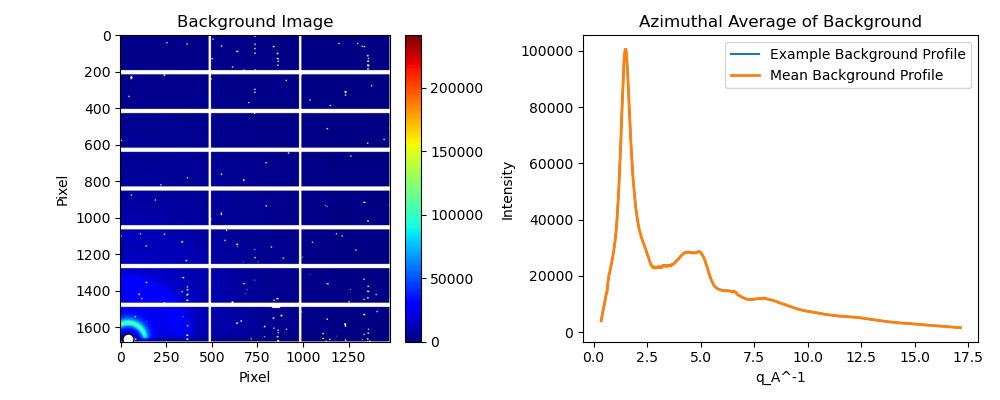

In [122]:
# Background path can be either:
# - a single tif file
# - or a folder containing many background tif files
# Load Data
print(f"Loading background from: {BACKGROUND_PATH}")
bg_dict = trxrd.load_background(
    background_path=BACKGROUND_PATH,
    sort=True,
    plot=False,
)

print(bg_dict.keys())
print("Background stack shape:", bg_dict["background_stack"].shape)
print("Background mean shape:", bg_dict["background_mean"].shape)

bg_dict["background_stack"] = trxrd.apply_mask_from_bool(
    data_array=bg_dict["background_stack"],
    mask_bool=combined_mask,
)


bg_dict["background_mean"] = np.nanmean(bg_dict["background_stack"], axis=0)


# Compute background azimuthal average
if PONI_FILE is not None:
    print(f"Using PONI geometry from file: {PONI_FILE} for background azimuthal average.")
    bg_az_result = trxrd.compute_background_azimuthal_average(
        background_input=bg_dict["background_stack"],
        centers_xy=None,   # one average center in (x, y)
        poni_path=PONI_FILE,
        npt=N_POINTS,
        unit=UNIT,
        nan_radial_range=(NAN_MIN, NAN_MAX),   # set Q < 0.3 to NaN
        azimuth_range=None,
        integration_mask=combined_mask,
        return_dict=True,
        progress_interval=100,
        use_custom_polarization=False,
        integration_function="integrate1d",
        correct_solid_angle=False,
        plot=True,
    )
else:
    bg_az_result = trxrd.compute_background_azimuthal_average(
        background_input=bg_dict["background_stack"],
        centers_xy=(CENTER_X, CENTER_Y),   # one average center in (x, y)
        unit=UNIT,
        polarization_factor=POLARIZATION_FACTOR,
        npt=N_POINTS,
        use_custom_polarization=False,
        integration_function="integrate1d",
        correct_solid_angle=False,
        plot=True,
    )

q_bg = bg_az_result["radial"]
background_profile = bg_az_result["background_profile_mean"]



## Subtract Scaled Background from Images

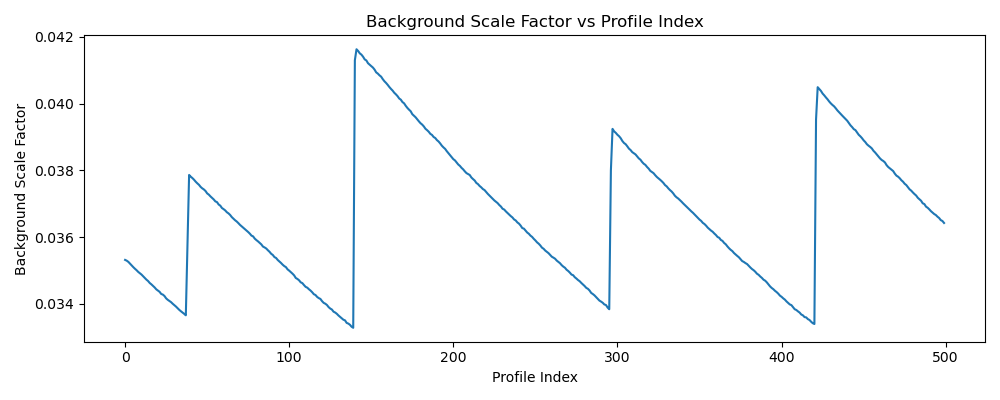

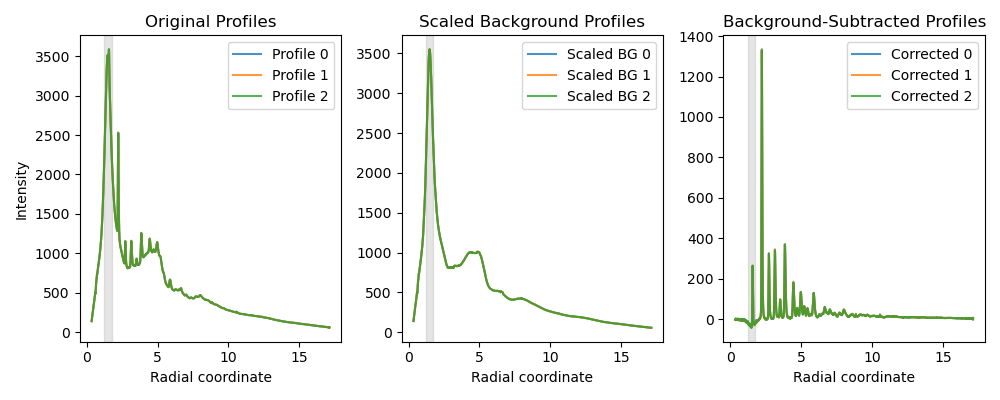

In [123]:
bgsub_result = trxrd.subtract_scaled_background_profile(
    radial=q,
    profiles=profiles,
    background_profile=background_profile,
    norm_range=(1.25, 1.75),   # example region; adjust as needed
    mode="mean",
    scale_method="ratio",
    plot=True,
    plot_scale_factors=True,
    plot_indices=[0, 1, 2],
    return_dict=True,
)

profiles_bgsub = bgsub_result["corrected_profiles"]
baselines = bgsub_result["scaled_background_profiles"]

# # Inspect Scaling Factors
# plt.figure(figsize=(8, 4))
# plt.plot(bgsub_result["scale_factors"])
# plt.xlabel("Image Index")
# plt.ylabel("Background Scale Factor")
# plt.title("Background Scale Factors")
# plt.show()

## Save Background

In [111]:
df = pd.DataFrame({
    "q": q_bg,
    "I(q)": baselines[0]/1000   # example: save the baseline for the first image
})

df.to_csv(
    f"{SAVE_PATH}/{COMPOSITION}_background.dat",
    sep=" ",
    index=False
)

## Check Drifts with SVD

dict_keys(['U', 'S', 'Vt', 'variance_explained', 'reconstruction', 'axis_values', 'time_values'])
Singular values (dI): [101528.04180941   4203.4581776     345.37452958    227.65651515
    181.41058718]
Variance explained: [9.98088059e-01 1.71084357e-03 1.15498795e-05 5.01830447e-06
 3.18655998e-06]


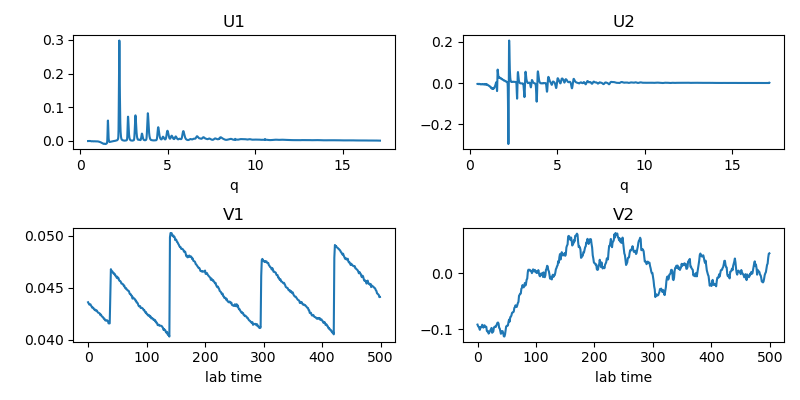

In [124]:
matrix = profiles_bgsub.T  # shape (n_q, n_delays)

svd_dict = trxrd.svd_analysis(
    data=matrix[20:, :], 
    axis_values=q[20:],
    time_values=data_dict["delay"]
)
print(svd_dict.keys())

# Inspect
print("Singular values (dI):", svd_dict['S'][:5])
print("Variance explained:", svd_dict['variance_explained'][:5])

# Plot first two components

fig, axes = plt.subplots(2, 2, figsize=(8, 4))
for i in range(2):
    axes[0, i].plot(q[20:], svd_dict['U'][:, i])
    axes[0, i].set_xlabel('q'); axes[0, i].set_title(f'U{i+1}')
    axes[1, i].plot(svd_dict['Vt'][i, :])
    axes[1, i].set_xlabel('lab time'); axes[1, i].set_title(f'V{i+1}')
plt.tight_layout()

## Track and Correct Peak Drift

Detected 5 peak(s) at q = [1.57734149 2.22695497 2.72536531 3.15097414 3.85658878]


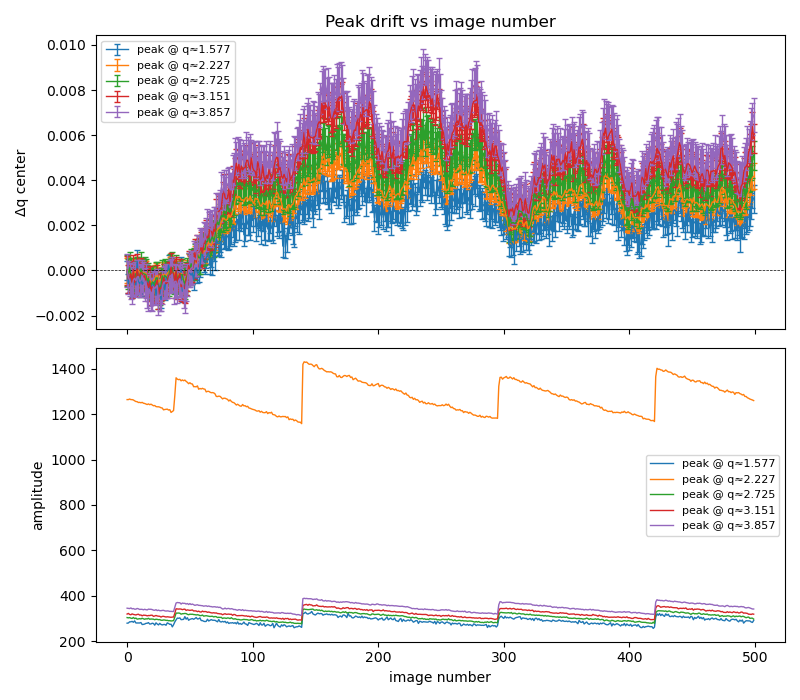

In [125]:
# q: (Nq,), I_stack: (Nq, Nimg)
results = trxrd.track_peaks(
    q, profiles_bgsub.T,
    ref="mean",          # average pattern is more robust than image 0
    prominence=200,      # <-- tune this; main knob for detection
    distance=1,          # min samples between peaks
)

fig, axes = trxrd.plot_drift(results, relative=True)
plt.show()

## Apply q Correction

In [24]:
s = trxrd.scale_drift_factor(results)
# Step 2: apply correction
q_corr, I_corr = trxrd.apply_scale_correction(q, profiles_bgsub.T, s, kind="cubic")

# Step 3: verify by re-running peak tracking on corrected data
results_corr, summary = trxrd.verify_correction(
    q_corr, I_corr, results,
    track_peaks_fn=trxrd.track_peaks,
    prominence=150,    # same as your original call
)

Trimmed 15 q points to avoid extrapolation.
Output q range: [0.3350, 17.0243]
Detected 6 peak(s) at q = [1.57104009 2.21981845 2.71758806 3.14264975 3.84176436 4.44020648]


c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd\analysis.py:1605: RuntimeWarning: Mean of empty slice
  I_ref = np.nanmean(I_stack, axis=1)


    Peak q     Before (pp)      After (pp)   Reduction
-------------------------------------------------------
     1.577        4.92e-03        6.38e-04       87.0%
     2.225        4.02e-03        6.28e-04       84.4%
     2.723        3.95e-03        7.58e-04       80.8%
     3.148        4.41e-03        6.30e-04       85.7%
     3.853        3.99e-03        7.10e-04       82.2%
     4.446        4.07e-03        8.08e-04       80.1%


## Subtract Baseline from Images

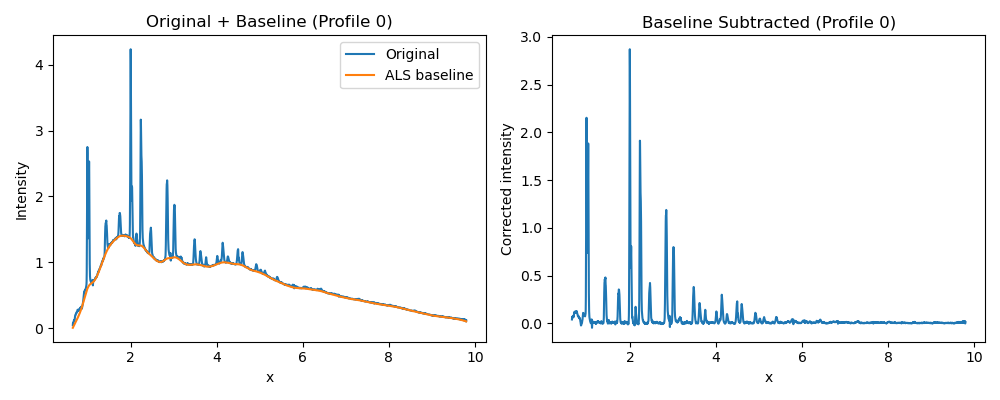

In [32]:
als_result = trxrd.subtract_als_baseline(
    data_array=profiles_norm,
    x_vals=q,
    lam=1e4,
    p=0.005,
    niter=10,
    plot=True,
    return_dict=True,
)

profiles_flat = als_result["corrected_data"]
baselines = als_result["baselines"]


## Make Reference Profile

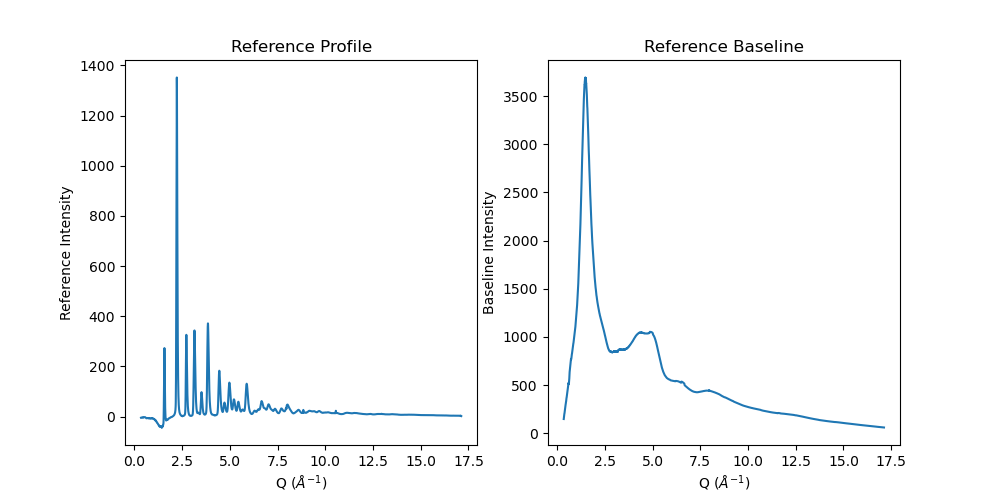

In [126]:
ref_result = trxrd.make_reference_profile(
    profiles=profiles_bgsub,
    delays=data_dict["delay"],
    reference_selector=None,
    return_dict=True,
)

ref_baseline = trxrd.make_reference_profile(
    profiles=baselines,
    delays=data_dict["delay"],
    reference_selector=None,
    return_dict=True,
)

reference_profile = ref_result["reference_profile"]
reference_baseline = ref_baseline["reference_profile"]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(q, reference_profile)
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Reference Intensity")
plt.title("Reference Profile")

plt.subplot(1, 2, 2)
plt.plot(q, reference_baseline)
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Baseline Intensity")
plt.title("Reference Baseline")

plt.show()

## Compute Difference Profiles

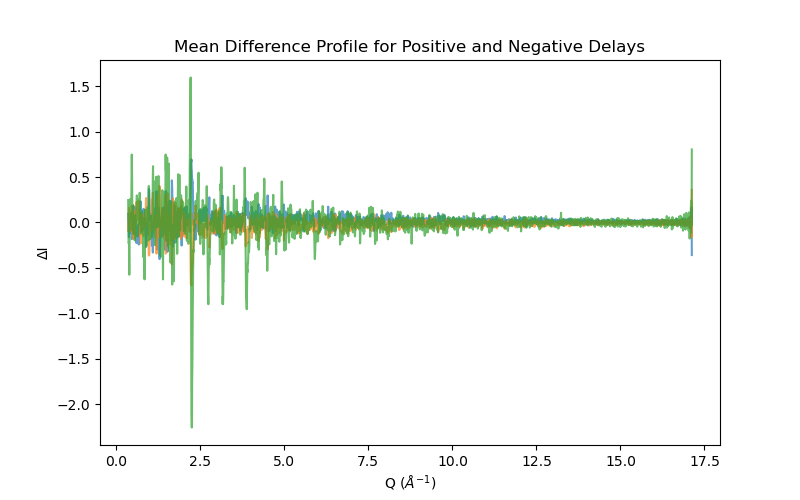

In [127]:
delta_result = trxrd.compute_delta_profiles(
    profiles=profiles_bgsub,
    reference_profile=reference_profile,
    mode="subtract",
    return_dict=True,
)

baseline_results = trxrd.compute_delta_profiles(
    profiles=baselines,
    reference_profile=reference_baseline,
    mode="subtract",
    return_dict=True,
)

delta_profiles = delta_result["delta_profiles"]
delta_baselines = baseline_results["delta_profiles"]


plt.figure(figsize=(8, 5))
for delay in np.unique(data_dict["delay"]):
    mean_profile = np.mean(delta_profiles[np.where(data_dict["delay"] == delay)[0]], axis=0)
    plt.plot(q, mean_profile, alpha=0.7, label=f"Delay {delay} ps")
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("ΔI")
plt.title("Mean Difference Profile for Positive and Negative Delays")
#plt.legend()
plt.show()

## Average by Delay

c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd\analysis.py:753: RuntimeWarning: Mean of empty slice
  mean_profiles[i] = np.nanmean(group, axis=0)


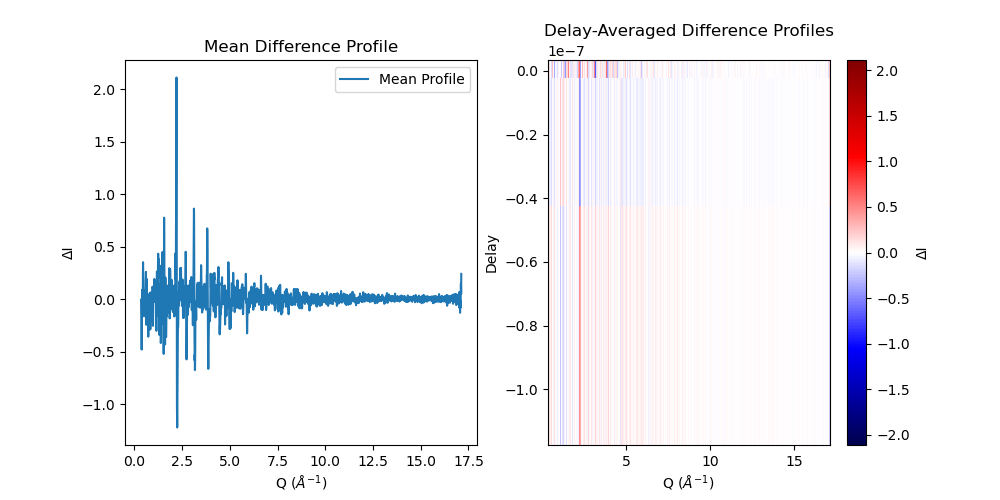

In [116]:
delay_result = trxrd.average_profiles_by_delay(
    profiles=delta_profiles,
    delays=data_dict["delay"],
    unique_delays=None,
    return_dict=True,
)

unique_delays = delay_result["unique_delays"]
mean_profiles = delay_result["mean_profiles"]

# Plot Heatmap of mean profiles vs delay
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.plot(q, mean_profiles[-1], label="Mean Profile")
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("ΔI")
plt.title("Mean Difference Profile")
plt.legend()

plt.subplot(1,2,2)
plt.pcolormesh(q, unique_delays, mean_profiles, shading="auto", cmap="seismic")
plt.colorbar(label="ΔI")
#plt.ylim(-2e-8, 1e-8)
plt.clim(-np.nanmax(mean_profiles), np.nanmax(mean_profiles))  # set color limits for better contrast; adjust as needed
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Delay")
plt.title("Delay-Averaged Difference Profiles")
plt.show()

## Perform SVD

Singular values (dI): [7.79316198e+00 4.39833809e+00 5.03740204e-12]
Variance explained: [7.58420585e-01 2.41579415e-01 3.16880805e-25]


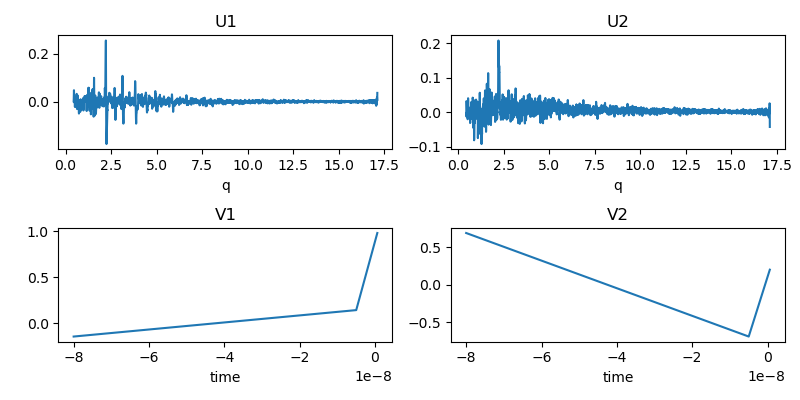

In [117]:
matrix = mean_profiles.T  # shape (n_q, n_delays)

svd_dict = trxrd.svd_analysis(
    data=matrix[20:, :], 
    axis_values=q[20:],
    time_values=unique_delays
)
svd_dict.keys()

# Inspect
print("Singular values (dI):", svd_dict['S'][:5])
print("Variance explained:", svd_dict['variance_explained'][:5])

# Plot first two components

fig, axes = plt.subplots(2, 2, figsize=(8, 4))
for i in range(2):
    axes[0, i].plot(q[20:], svd_dict['U'][:, i])
    axes[0, i].set_xlabel('q'); axes[0, i].set_title(f'U{i+1}')
    axes[1, i].plot(unique_delays, svd_dict['Vt'][i, :])
    axes[1, i].set_xlabel('time'); axes[1, i].set_title(f'V{i+1}')
plt.tight_layout()

## Plot Lineouts 

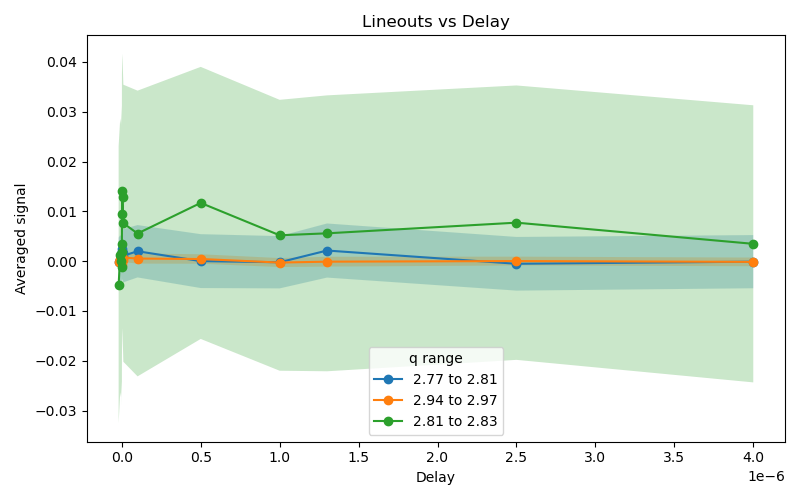

In [17]:
lineout_result = trxrd.lineouts_by_delay_from_per_image_profiles(
    radial=q,
    delta_profiles=delta_profiles,
    delays=data_dict["delay"],
    q_ranges=[(2.77, 2.81), (2.94, 2.97), (2.815, 2.83)],
    average_mode="mean",
    error_type="sem",
    plot=True,
    return_dict=True,
)

## Check Baseline per Delay

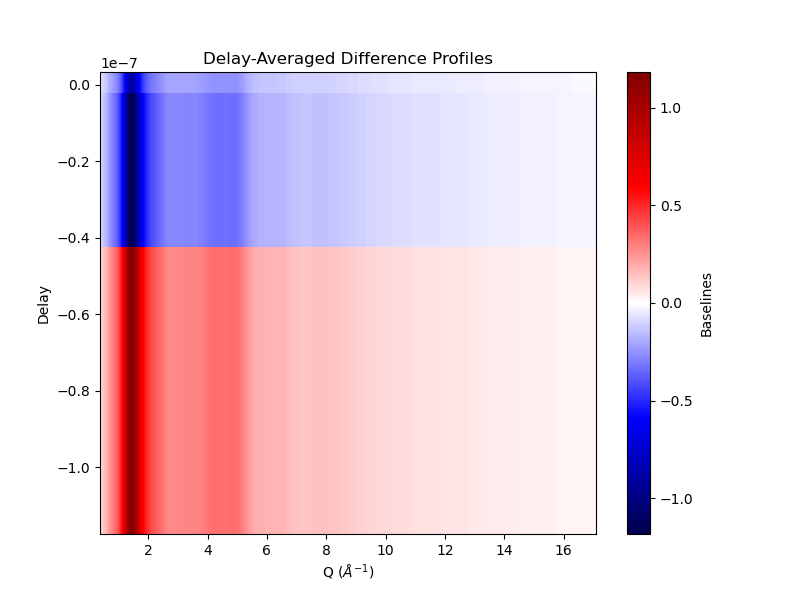

In [20]:
delay_result = trxrd.average_profiles_by_delay(
    profiles=delta_baselines,
    delays=data_dict["delay"],
    unique_delays=None,
    return_dict=True,
)

unique_delays = delay_result["unique_delays"]
mean_bkgs = delay_result["mean_profiles"]
std_bkgs = delay_result["std_profiles"]

# Plot Heatmap of mean profiles vs delay
plt.figure(figsize=(8, 6))
plt.pcolormesh(q, unique_delays, mean_bkgs, shading="auto", cmap="seismic")
plt.colorbar(label="Baselines")
#plt.clim(-0.02, 0.02)  # set color limits for better contrast; adjust as needed
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Delay")
plt.title("Delay-Averaged Difference Profiles")
plt.show()

## Calculate f and f(2)

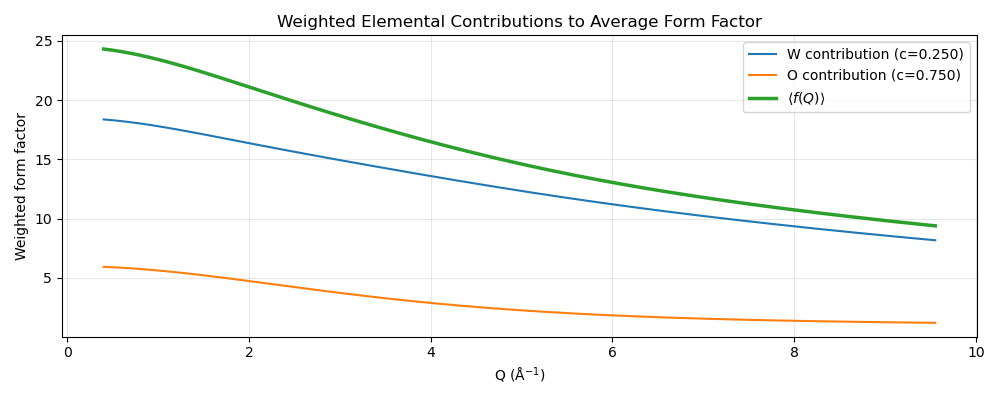

In [24]:
ff_results = trxrd.compute_average_form_factors(q, COMPOSITION, plot=True)

f_avg = ff_results["f_avg"]
f2_avg = ff_results["f2_avg"]


## Apply I(Q) High Q Correction Based on Form Factors

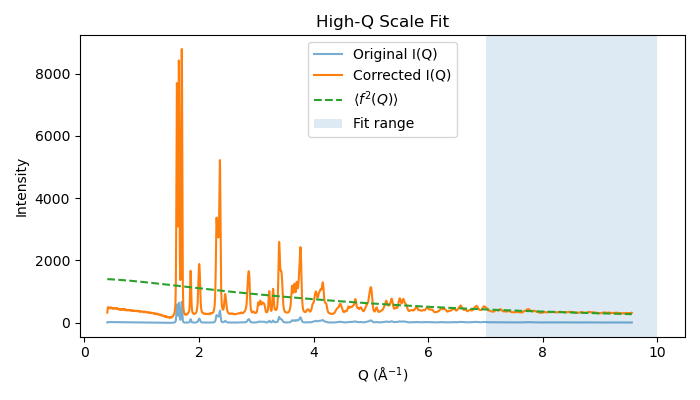

In [26]:
corr = trxrd.correct_iq(
    q=q,
    iq=profiles_bgsub,
    composition=COMPOSITION,
    q_fit_range=(7,10),
    background="constant",
    plot=True,
    return_dict=True,
)

iq_corrected = corr["iq_corrected"]

## Calculate S(Q) and F(Q)

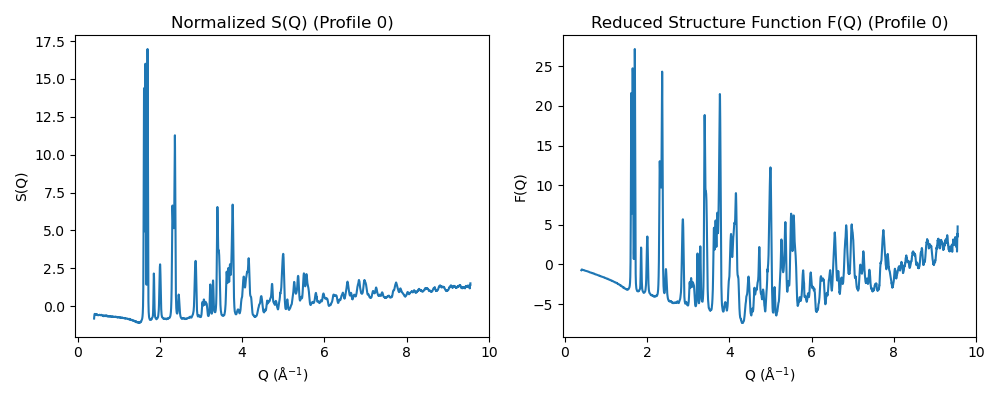

In [27]:
sq_result = trxrd.normalize_xray_scattering_to_sq_fq(
    q=q,
    iq=iq_corrected,
    composition=COMPOSITION,
    mode="total",
    plot=True,
    return_dict=True,
)

sq = sq_result["sq"]
fq = sq_result["fq"]


## Optional Polynomial Correction

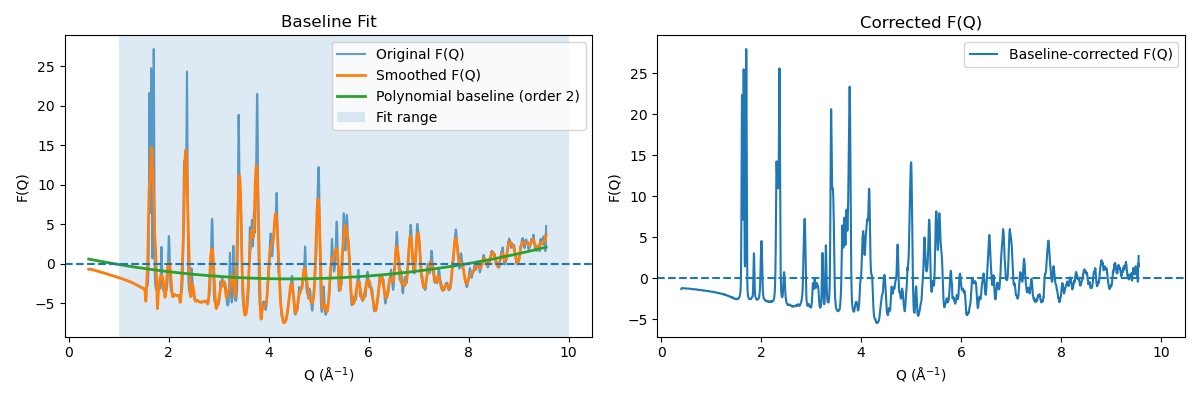

In [31]:
fq_corr_result = trxrd.apply_polynomial_baseline(
    q=q,
    fq=fq,
    q_fit_range=(1.0, 10.0),   # or maybe (10.0, 17.0)
    poly_order=2,
    smooth_window=51,
    smooth_polyorder=3,
    plot=True,
    return_dict=True,
)

fq_corrected = fq_corr_result["fq_corrected"]

## Calculate G(r)

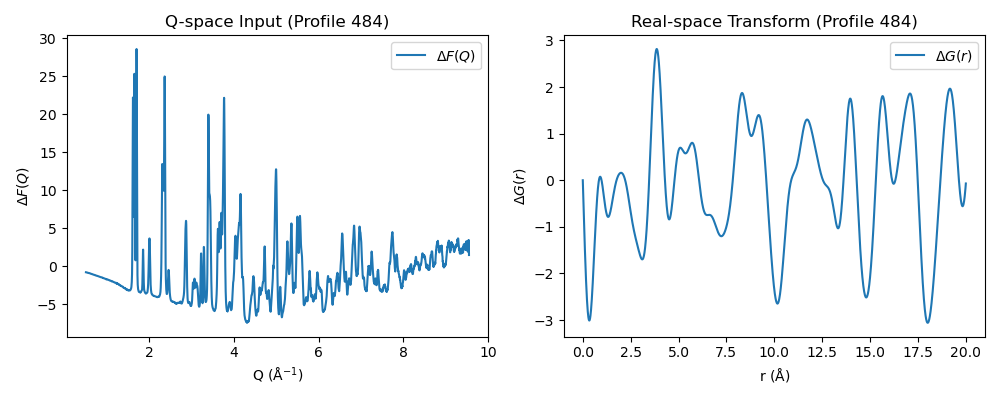

(485, 2000)


In [32]:
Gr_result = trxrd.compute_delta_gr_from_delta_fq(
    q=q,
    delta_fq=fq,
    r_max=R_MAX,
    n_r=N_R,
    q_range=(Q_MIN, Q_MAX),
    window=WINDOW,
    plot=True,
    profile_index=len(fq)-1,  # example: use last profile (e.g. longest delay)
    return_dict=True,
)

r = Gr_result["r"]
Gr_profiles = Gr_result["delta_gr"]
print(Gr_profiles.shape)   # should be (n_profiles, n_r)


Gr_delay_result = trxrd.average_profiles_by_delay(
    profiles=Gr_profiles,
    delays=data_dict["delay"],
    unique_delays=None,
    return_dict=True,
)

unique_delays = Gr_delay_result["unique_delays"]
mean_Gr = Gr_delay_result["mean_profiles"]
r = Gr_result["r"]

## Calculate dS(Q) and dF(Q)

c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd.py:4564: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=True)


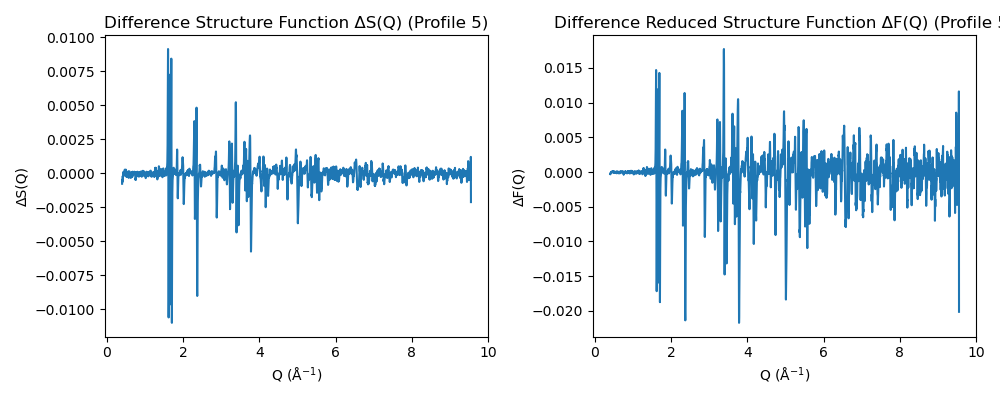

In [15]:
delta_result = trxrd.normalize_xray_scattering_to_sq_fq(
    q=q,
    iq=mean_profiles,  # example: use mean profiles for normalization
    composition=COMPOSITION,
    mode="difference",
    plot=True,
    profile_index=len(mean_profiles)-1,  # example: use last profile (e.g. longest delay)
    return_dict=True,
)


delta_sq = delta_result["delta_sq"]
delta_fq = delta_result["delta_fq"]

## Calculate dG(r)

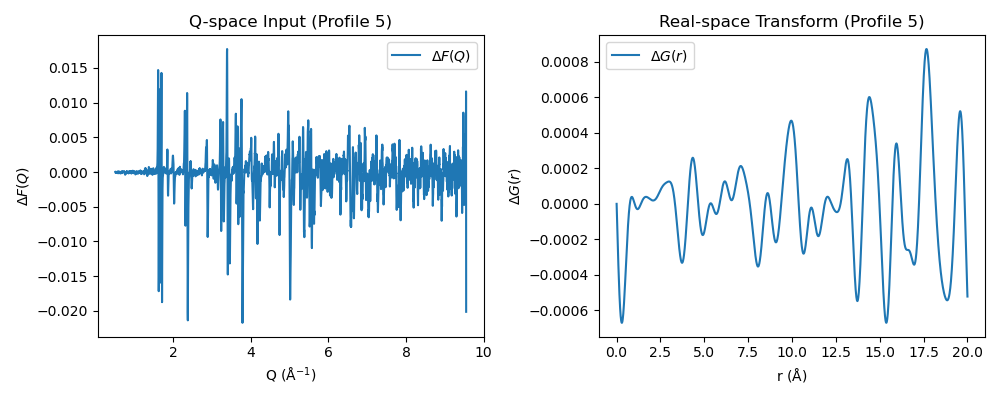

(6, 2000)


In [16]:
dGr_result = trxrd.compute_delta_gr_from_delta_fq(
    q=q,
    delta_fq=delta_fq,
    r_max=R_MAX,
    n_r=N_R,
    q_range=(Q_MIN, Q_MAX),
    window=WINDOW,
    plot=True,
    profile_index=len(delta_fq)-1,  # example: use last profile (e.g. longest delay)
    return_dict=True,
)

r = dGr_result["r"]
dGr_profiles = dGr_result["delta_gr"]
print(dGr_profiles.shape)   # should be (n_profiles, n_r)

## Plot Delay Averaged dG(r)

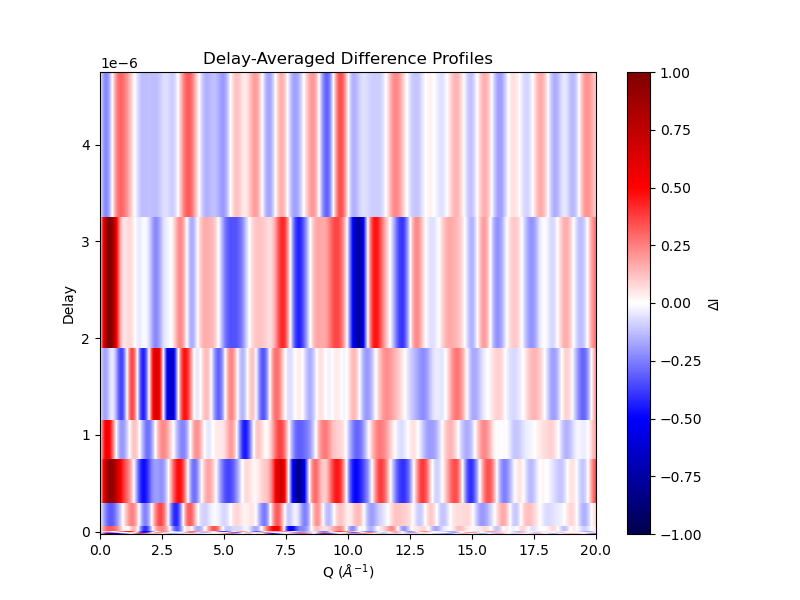

In [23]:
# Plot Heatmap of mean profiles vs delay
plt.figure(figsize=(8, 6))
plt.pcolormesh(r, unique_delays, dGr_profiles/np.nanmax(dGr_profiles), shading="auto", cmap="seismic")
plt.colorbar(label="ΔI")
plt.clim(-1, 1)  # set color limits for better contrast; adjust as needed
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Delay")
plt.title("Delay-Averaged Difference Profiles")
plt.show()

## Compare Results

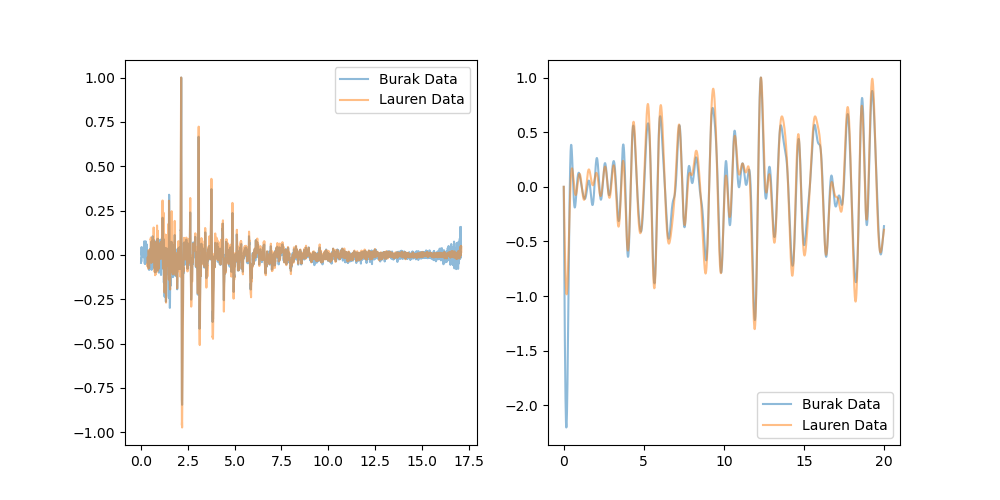

In [35]:
df = pd.read_excel("C:\\Users\\lheald\\Documents\\Guzelturk_Lab\\TRXRDPython\\testdata\\output\\BaTiO3_data_CottsExp_Nov25.xlsx", header=2)

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.plot(df["Q"], df["deltaI(Q,0.6ns)"]/np.nanmax(df["deltaI(Q,0.6ns)"]), alpha=0.5, label="Burak Data")
plt.plot(q, mean_profiles[-1]/np.nanmax(mean_profiles[-1]), alpha=0.5, label="Lauren Data")
#plt.xlim(0,10)
plt.legend()

plt.subplot(1,2,2)
plt.plot(df["r"], df["deltaG(r,0.6ns)"]/np.nanmax(df["deltaG(r,0.6ns)"]), alpha=0.5, label="Burak Data")
plt.plot(r, dGr_profiles[-1]/np.nanmax(dGr_profiles[-1]), alpha=0.5, label="Lauren Data")
plt.legend()
plt.show()


In [23]:
# to_csv = {"q": q,
#           "deltaI_0.6ns": mean_profiles[2],
#           "deltaI_-5ns": mean_profiles[1],
#           }

# pd.DataFrame(to_csv).to_csv("BaTiO3_deltaI_profiles.csv", index=False)

to_csv = {"r": r, 
          "dGr_0": dGr_profiles[0],
          "dGr_1": dGr_profiles[1],
          "dGr_2": dGr_profiles[2],
          "dGr_3": dGr_profiles[3],
          "dGr_4": dGr_profiles[4],
          "dGr_5": dGr_profiles[5],
          }

pd.DataFrame(to_csv).to_csv("WO3_deltaGr_profile.csv", index=False)

In [21]:
unique_delays

array([-8.e-08, -1.e-08,  1.e-10,  2.e-10,  1.e-09,  1.e-07])

## Load PDF from Crystal Maker/PDFgetX3

Try smoothing with moving average or lowess filter etc to make more like experimental data

In [24]:
r_vals_cm, pdf_vals_cm = np.loadtxt("C:\\Users\\lheald\\Downloads\\BaTiO3 graph data.txt", skiprows=3, unpack=True)
dr = r_vals_cm[1] - r_vals_cm[0]
pdf_smooth_cm = gaussian_filter1d(pdf_vals_cm, sigma=2)

r_pdfget, pdf_pdfget = np.loadtxt("C:\\Users\\lheald\\Documents\\Guzelturk_Lab\\Cotts_Processed_Data\\BTO400nmS3_240Ksurv3_10uJ_-0fs_00000.gr", skiprows=26, unpack=True)


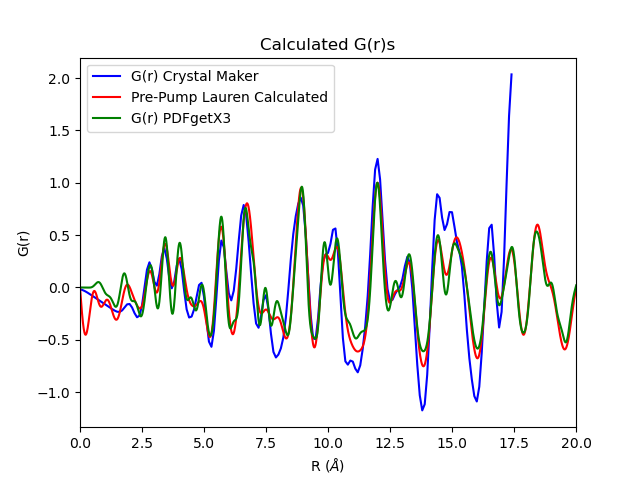

In [33]:
plt.figure()
#plt.plot(r_vals, pdf_vals)
plt.plot(r_vals_cm, pdf_smooth_cm/25, label="G(r) Crystal Maker", color="blue")
plt.plot(r, mean_Gr[0]/np.nanmax(mean_Gr[0]), label="Pre-Pump Lauren Calculated", color="red")
plt.plot(r_pdfget, pdf_pdfget/np.nanmax(pdf_pdfget), label="G(r) PDFgetX3", color="green")
# plt.plot(r, (dGr_profiles[-1]*5/np.nanmax(dGr_profiles[-1])) - 10, label="dG(r)", color="red")
# plt.plot(r, mean_Gr[-1], label="post-pump")
plt.xlabel(r"R ($\AA$)")
plt.ylabel("G(r)")
plt.title("Calculated G(r)s")
plt.legend()
plt.xlim(0, 20)
#plt.ylim(-3, 3)
plt.show()

## Save Results

In [ ]:
# np.savez(
#     "trxrd_processed_results.npz",
#     q=q,
#     delays=clean_dict["delay"],
#     image_numbers=clean_dict["image_number"],
#     centers=centers,
#     profiles=profiles,
#     profiles_bgsub=profiles_bgsub,
#     profiles_norm=profiles_norm,
#     reference_profile=reference_profile,
#     delta_profiles=delta_profiles,
#     unique_delays=unique_delays,
#     mean_profiles=mean_profiles,
#     std_profiles=std_profiles,
# )

: 